# Analysis of Barren Plateau Mitigation Techniques in VQE

This implementation provides a systematic evaluation of multiple barren plateau mitigation techniques using both gradient-based diagnostics and performance metrics. The analysis framework implements five distinct VQE variants and comprehensive diagnostic tools for studying quantum optimization landscapes.

The analysis system consists of:

### Core Components

- **BarrenPlateauAnalyzer**: Main analysis engine implementing five VQE variants
- **BarrenPlateauVisualizer**: Comprehensive visualization suite for results analysis
- **Gradient-based diagnostics**: Statistical analysis of optimization landscapes
- **Performance metrics**: Energy convergence and state fidelity evaluation

### VQE Methods Analyzed

1. **Standard VQE**: Baseline implementation using EfficientSU2 ansatz
2. **Local-Global VQE**: Two-stage optimization strategy
3. **Adiabatic VQE**: Gradual Hamiltonian transition approach
4. **State Efficient Ansatz (SEA)**: Reduced expressivity circuit design
5. **Pretrained VQE**: MPS-based parameter initialization

### Analysis Features

- **Comprehensive diagnostics**: Gradient variance, norm statistics, and landscape curvature
- **Performance assessment**: Energy error analysis and convergence behavior
- **Visualization suite**: Energy convergence, gradient landscapes, and statistical distributions
- **Comparative analysis**: Method-to-method performance and barren plateau severity comparison

### Generated Outputs

- Energy convergence comparison plots
- Barren plateau diagnostic visualizations
- Loss and gradient landscape mappings
- Statistical distribution analysis
- Comprehensive performance summary tables

### Configuration Parameters

- **System size**: 6 qubits (configurable)
- **Optimization iterations**: 5000 per method
- **Landscape resolution**: 20×20 grid sampling
- **Analysis depth**: Complete gradient and performance profiling

### Key Metrics

- **Energy accuracy**: Final ground state energy error
- **State fidelity**: Overlap with exact ground state
- **Gradient statistics**: Variance, mean norm, and distribution analysis
- **Convergence behavior**: Optimization trajectory analysis

### Results Classification

The system automatically classifies results using performance thresholds:

- **Performance**: Excellent (< 1e-3), Good (< 1e-2), Fair (< 1e-1), Poor (≥ 1e-1)
- **Barren plateau severity**: Minimal (< 1e-4), Moderate (< 1e-3), Significant (< 1e-2), Severe (≥ 1e-2)

### References

1. McClean, J. R., Boixo, S., Smelyanskiy, V. N., Babbush, R., & Neven, H. (2018). Barren plateaus in quantum neural network training landscapes. *Nature Communications*, 9(1), 4812.

2. Cerezo, M., Sone, A., Volkoff, T., Cincio, L., & Coles, P. J. (2021). Cost function dependent barren plateaus in shallow parametrized quantum circuits. *Nature Communications*, 12(1), 1791.

3. Nemkov, N. (2025). Statistical models of barren plateaus and anti-concentration of Pauli observables. *arXiv preprint arXiv:2505.08758*.

#### Implementation Notes

Based on the qubap (Quantum Barren Plateaus) library framework with extended analysis capabilities and comprehensive visualization tools for systematic barren plateau research.

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np

# Add parent directory for imports
sys.path.append("./../")

# Import modules with error handling
from src.barren_plateau_analyzer import BarrenPlateauAnalyzer
from src.visualization import BarrenPlateauVisualizer

from src.barren_plateau_analyzer import BarrenPlateauAnalyzer
from qubap.qiskit.state_efficient_ansatz import ansatz_constructor
from qiskit.circuit.library import EfficientSU2

In [2]:
def print_summary(analyzer):
    """Print a simple summary of results."""
    print("\n" + "=" * 60)
    print("ANALYSIS SUMMARY")
    print("=" * 60)

    if not analyzer.results:
        print("❌ No results available")
        return None

    # Create summary table
    data = []
    for method_name, result in analyzer.results.items():
        try:
            method_data = result["method_results"]
            bp_data = result["bp_diagnostics"]
            perf_data = result["performance_metrics"]
            
            data.append({
                'Method': method_name,
                'Energy Error': f"{perf_data['final_energy_error']:.2e}",
                'Fidelity': f"{perf_data['state_fidelity']:.3f}",
                'Grad Variance': f"{bp_data['gradient_variance']:.2e}",
                'Status': 'Success'
            })
        except Exception as e:
            data.append({
                'Method': method_name,
                'Energy Error': 'N/A',
                'Fidelity': 'N/A', 
                'Grad Variance': 'N/A',
                'Status': 'Failed'
            })

    # Print table
    df = pd.DataFrame(data)
    print(df.to_string(index=False))
    
    return df

def debug_sea_ansatz(num_qubits):
    """Debug SEA ansatz construction for specific qubit number."""
    print(f"   Debugging SEA ansatz for {num_qubits} qubits...")
    
    # Try different deep configurations
    configs = [
        [1, 1, 1],
        [1, 1], 
        [1],
        [2] if num_qubits >= 2 else [1],
        [1] * min(num_qubits, 3)  # Adaptive config
    ]
    
    for i, deep_config in enumerate(configs):
        try:
            print(f"    Trying config {i+1}: deep={deep_config}")
            ansatz = ansatz_constructor(num_qubits, deep=deep_config, set_barrier=True)
            print(f"     Success: {ansatz.num_parameters} parameters")
            return ansatz
        except Exception as e:
            print(f"     Failed: {e}")
            continue
    
    # Fallback to EfficientSU2
    print(f"    Using EfficientSU2 fallback...")
    return EfficientSU2(num_qubits, ["ry", "rz"], "linear", 1)


def create_safe_analyzer(num_qubits):
    """Create analyzer with safe ansatz construction."""
    
    class SafeAnalyzer(BarrenPlateauAnalyzer):
        def setup_ansatz(self):
            print(" Setting up ansatz with safety checks...")
            
            # Standard ansatz - usually works
            self.ansatz_standard = EfficientSU2(
                self.num_qubits, ["ry", "rz"], "circular", 0
            ).decompose()
            print(f"   Standard: {self.ansatz_standard.num_parameters} params")
            
            # Debug and create safe SEA ansatz
            self.ansatz_sea = debug_sea_ansatz(self.num_qubits)
            print(f"   SEA: {self.ansatz_sea.num_parameters} params")
            
            # MPS ansatzes with error handling
            try:
                from qubap.qiskit.mps_pretraining import Ansatz
                self.ansatz_mps = Ansatz(self.num_qubits, diagonal=True)
                self.ansatz_full = Ansatz(self.num_qubits, diagonal=False)
                print(f"   MPS: {self.ansatz_mps.num_parameters}, {self.ansatz_full.num_parameters} params")
            except Exception as e:
                print(f"    MPS failed, using EfficientSU2 fallback: {e}")
                self.ansatz_mps = EfficientSU2(self.num_qubits, ["ry"], "linear", 1)
                self.ansatz_full = EfficientSU2(self.num_qubits, ["ry", "rz"], "linear", 2)
    
    return SafeAnalyzer(num_qubits=num_qubits)

VQE BARREN PLATEAU ANALYSIS 

Configuration:
  Qubits: 6
  Iterations: 1000
  Output: ./analysis_6qubits

 Setting up analyzer...
Setting up Hamiltonian...
0.984375 * IIIIII
- 0.015625 * IIIIIZ
- 0.015625 * IIIIZI
- 0.015625 * IIIIZZ
- 0.015625 * IIIZII
- 0.015625 * IIIZIZ
- 0.015625 * IIIZZI
- 0.015625 * IIIZZZ
- 0.015625 * IIZIII
- 0.015625 * IIZIIZ
- 0.015625 * IIZIZI
- 0.015625 * IIZIZZ
- 0.015625 * IIZZII
- 0.015625 * IIZZIZ
- 0.015625 * IIZZZI
- 0.015625 * IIZZZZ
- 0.015625 * IZIIII
- 0.015625 * IZIIIZ
- 0.015625 * IZIIZI
- 0.015625 * IZIIZZ
- 0.015625 * IZIZII
- 0.015625 * IZIZIZ
- 0.015625 * IZIZZI
- 0.015625 * IZIZZZ
- 0.015625 * IZZIII
- 0.015625 * IZZIIZ
- 0.015625 * IZZIZI
- 0.015625 * IZZIZZ
- 0.015625 * IZZZII
- 0.015625 * IZZZIZ
- 0.015625 * IZZZZI
- 0.015625 * IZZZZZ
- 0.015625 * ZIIIII
- 0.015625 * ZIIIIZ
- 0.015625 * ZIIIZI
- 0.015625 * ZIIIZZ
- 0.015625 * ZIIZII
- 0.015625 * ZIIZIZ
- 0.015625 * ZIIZZI
- 0.015625 * ZIIZZZ
- 0.015625 * ZIZIII
- 0.015625 * ZIZIIZ
- 0.01

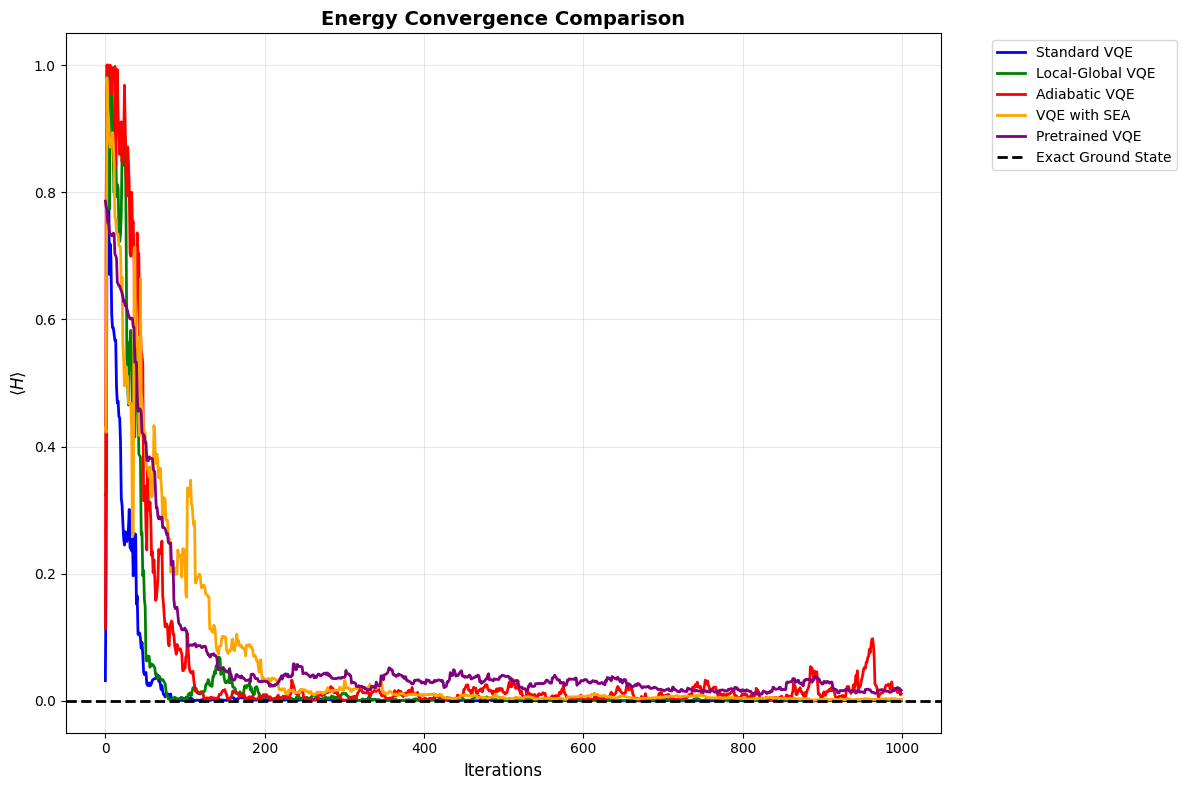

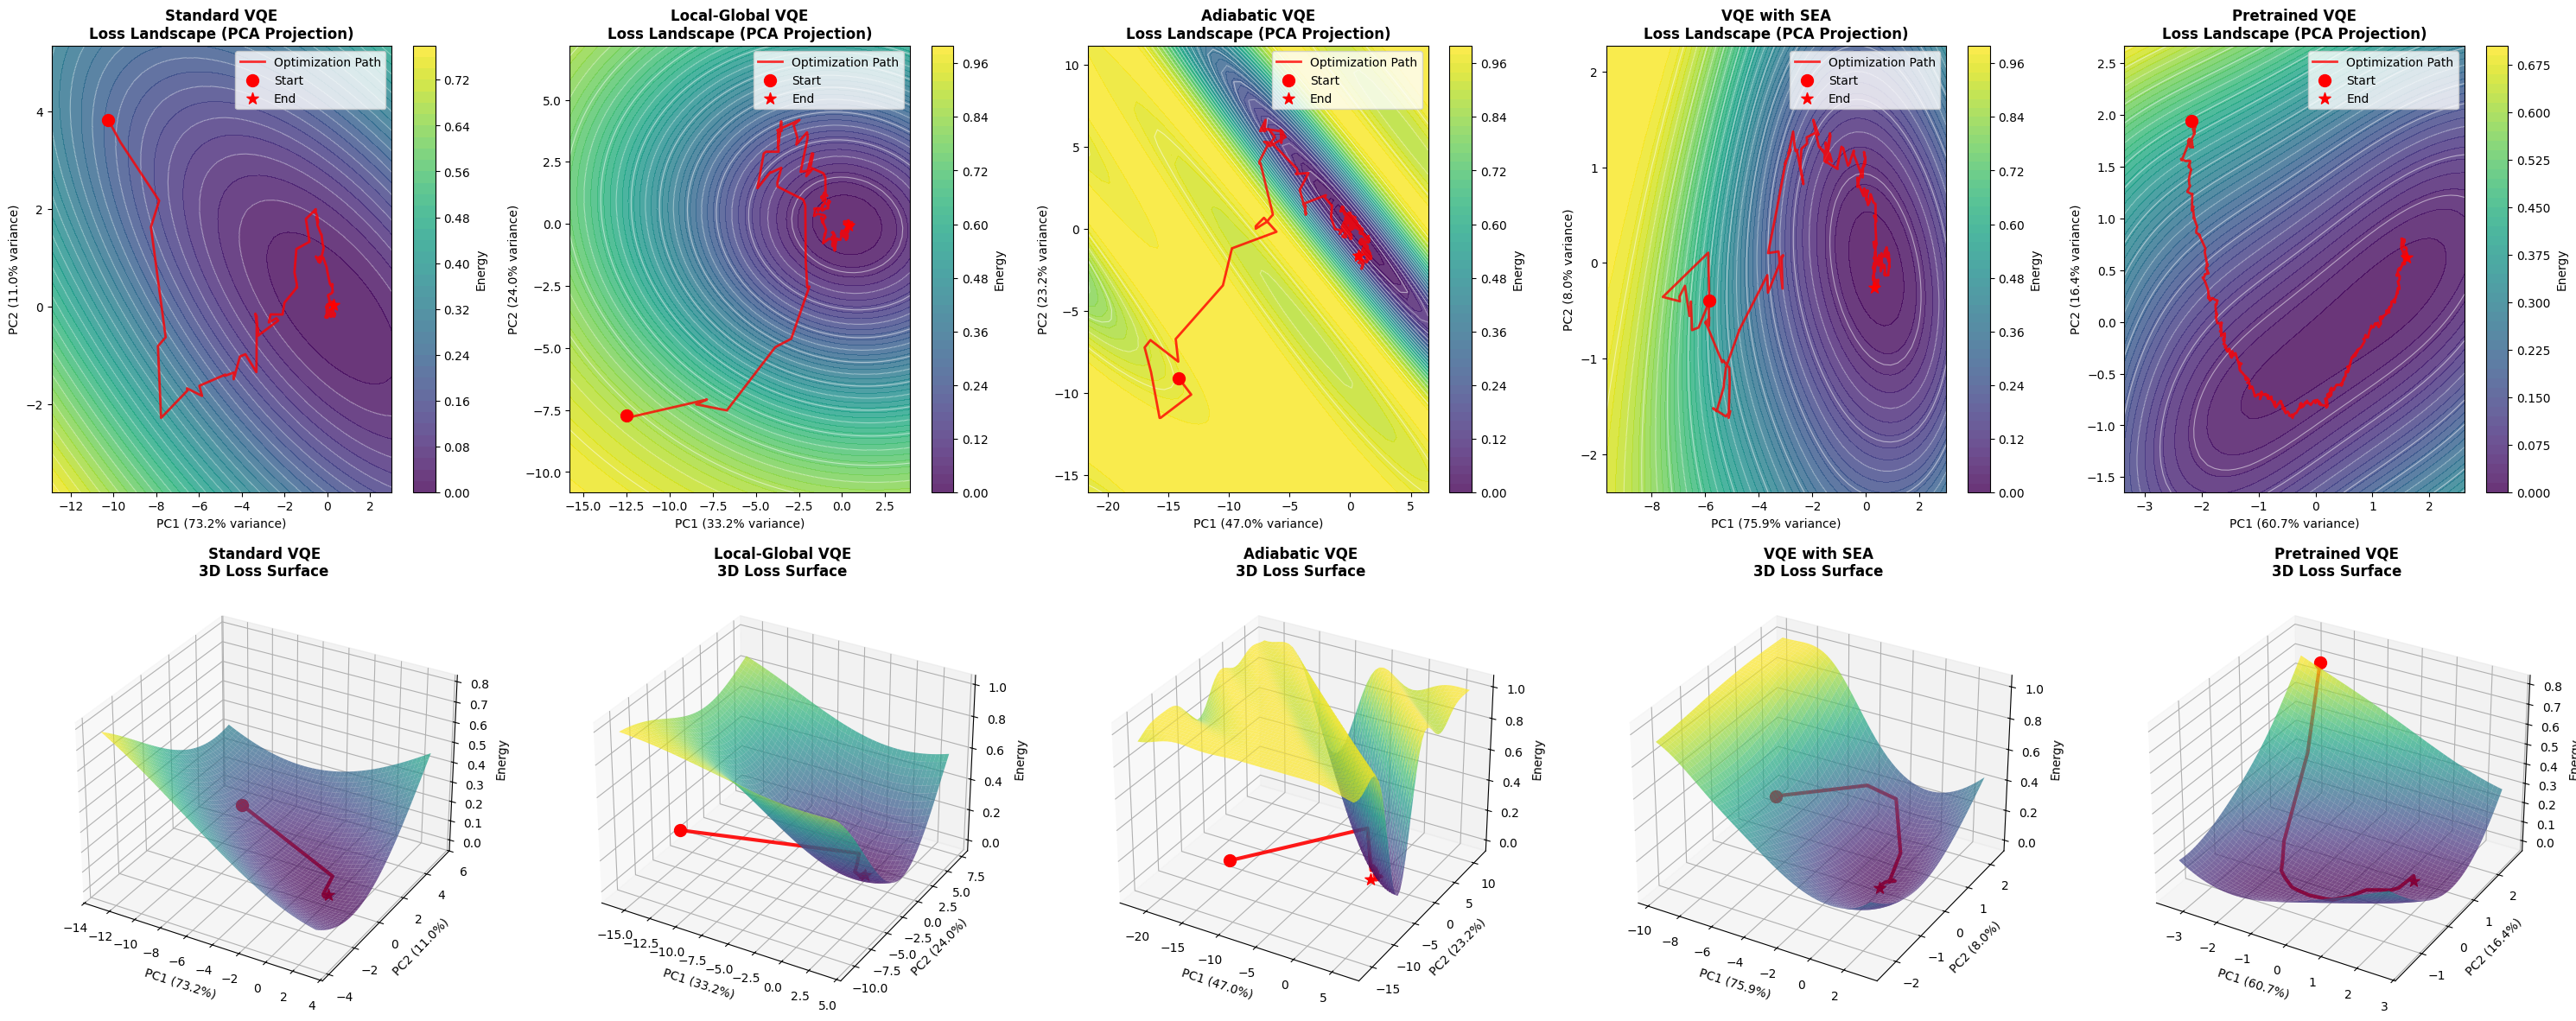

In [3]:
print("=" * 70)
print("VQE BARREN PLATEAU ANALYSIS ")
print("=" * 70)

# Simple configuration
NUM_QUBITS = 6
NUM_ITERATIONS = 1000
PLOTS_DIR = f"./analysis_{NUM_QUBITS}qubits"

print(f"\nConfiguration:")
print(f"  Qubits: {NUM_QUBITS}")
print(f"  Iterations: {NUM_ITERATIONS}")
print(f"  Output: {PLOTS_DIR}")

# Create output directory
Path(PLOTS_DIR).mkdir(parents=True, exist_ok=True)

# Setup analyzer
print(f"\n Setting up analyzer...")

analyzer = create_safe_analyzer(num_qubits=NUM_QUBITS)
print(" Analyzer ready")
    

# Run analysis
print(f"\n Running analysis...")
try:
    results = analyzer.run_complete_analysis(num_iters=NUM_ITERATIONS)
    if results:
        print(f" Analysis complete - {len(results)} methods analyzed")
    else:
        print(" Analysis failed")
        
except Exception as e:
    print(f" Analysis error: {e}")
    
# Print summary
summary_df = print_summary(analyzer)


# Generate plots including loss landscapes
print(f"\n Generating plots...")
try:
    visualizer = BarrenPlateauVisualizer(analyzer, output_dir=PLOTS_DIR)
    
    # Generate essential plots
    print("  - Energy convergence...")
    visualizer.plot_energy_convergence()
    
    print("  - Performance table...")
    visualizer.create_performance_table()
    
    print("  - Loss landscapes...")
    visualizer.plot_loss_landscapes(grid_size=50)  # Smaller grid for speed
    
    print(" All plots generated")
    
except Exception as e:
    print(f"  Some plots may have failed: {e}")
    # Try to generate at least basic plots
    try:
        print("  Attempting basic plots only...")
        visualizer.plot_energy_convergence()
        visualizer.create_performance_table()
        print(" Basic plots generated")
    except Exception as e2:
        print(f" All plotting failed: {e2}")

# Save summary
try:
    summary_path = os.path.join(PLOTS_DIR, "summary.csv")
    summary_df.to_csv(summary_path, index=False)
    print(f" Summary saved to: {summary_path}")
except Exception as e:
    print(f" Save error: {e}")

# Final results
print(f"\n Results:")
successful_methods = summary_df[summary_df['Status'] == 'Success']

if len(successful_methods) > 0:
    # Find best method (lowest energy error)
    energy_errors = []
    for _, row in successful_methods.iterrows():
        try:
            error_val = float(row['Energy Error'])
            energy_errors.append((row['Method'], error_val))
        except:
            continue
    
    if energy_errors:
        best_method = min(energy_errors, key=lambda x: x[1])
        worst_method = max(energy_errors, key=lambda x: x[1])
        
        print(f"   Best: {best_method[0]} (error: {best_method[1]:.2e})")
        print(f"   Worst: {worst_method[0]} (error: {worst_method[1]:.2e})")

print(f"\n Analysis complete! Check results in: {PLOTS_DIR}")
